In [1]:
import numpy as np
from scipy import stats
from scipy import signal
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

In [2]:
repo_root = Path('/home/tianhaoqiu/Documents/GitHub/2p_analysis')
sys.path.insert(0, str(repo_root))

In [3]:
from fly2p_function_TQ.imaging_2p_offset_and_behavior_distribution import get_PVA_heading_offset_and_turning_speed_distribution,plot_circular_variance_distribution_at_turning_slide_window,align_radian_offset_to_zero,plot_aligned_radian_offset_distribution

In [10]:
data_1 = get_PVA_heading_offset_and_turning_speed_distribution('/home/tianhaoqiu/Documents/GitHub/2p_analysis/preprocessing_output/normalized/ExR6/EPG_lexop8s_ExR6_Kir2.1/lexopjGCaMP8s_R27F02_lexA_SS53617_+/cl',separate_bridge = False,normalize_PVA_strength = True,signal_way = 'z')

In [11]:
data_2 = get_PVA_heading_offset_and_turning_speed_distribution('/home/tianhaoqiu/Documents/GitHub/2p_analysis/preprocessing_output/normalized/delta7_imaging_delta7_perturbation/delta7_RNAi_syt7f/R55G08_VGlut_syt7f/cl',separate_bridge = False,normalize_PVA_strength = True,signal_way = 'z')

In [12]:
all_aligned_data_combined_1 =align_radian_offset_to_zero(data_1,key_name='output_PVA_heading_offset')
all_aligned_data_combined_2 =align_radian_offset_to_zero(data_2,key_name='output_PVA_heading_offset')

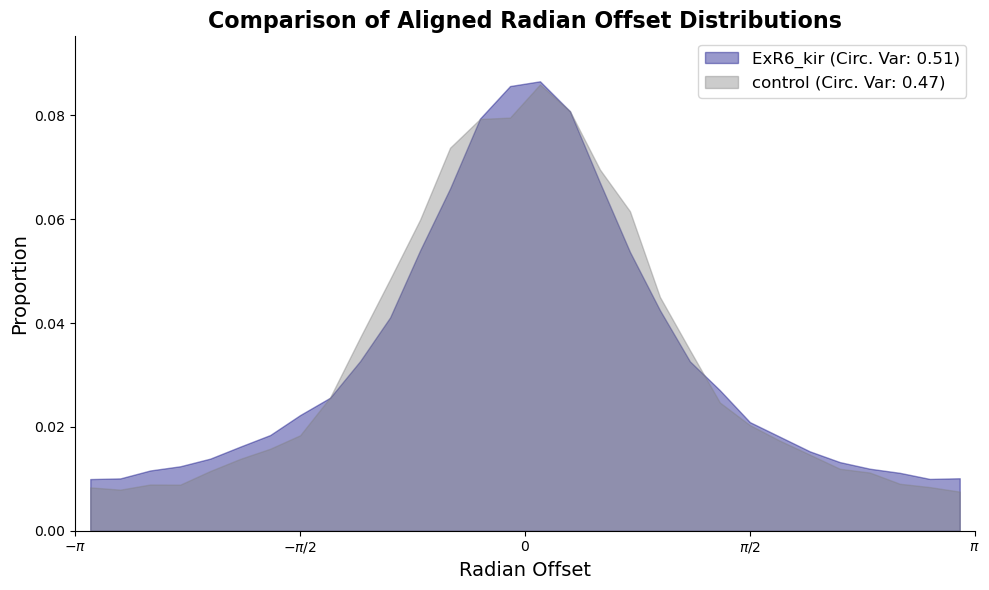

In [13]:
plot_aligned_radian_offset_distribution(aligned_radian_offset_1=all_aligned_data_combined_1 ,                                                                                                 
                                        aligned_radian_offset_2=all_aligned_data_combined_2,
                                        label_1="ExR6_kir", label_2="control",
                                        color_1="Navy",color_2="Grey", bins=30)

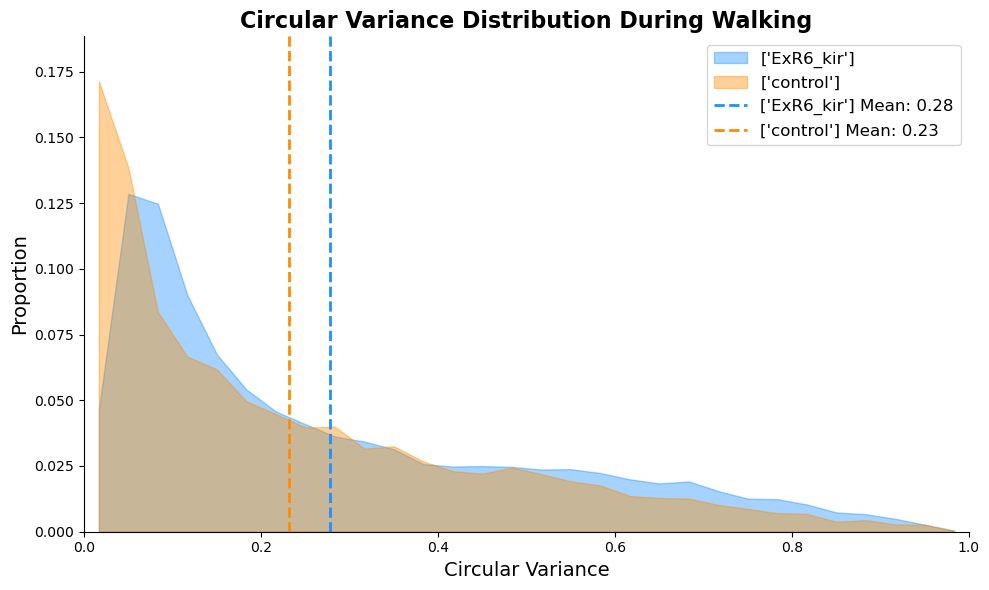

In [14]:
plot_circular_variance_distribution_at_turning_slide_window([data_1['circular_variance_slide_window_during_walking'],data_2['circular_variance_slide_window_during_walking']],[['ExR6_kir'],['control']])

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def plot_two_group_hist_pretty(
    group1_dict, group2_dict,
    trials=None,
    as_speed=False,                 # True -> |angular velocity|
    x_range=None,                   # (xmin, xmax) or None
    bins='auto',                    # int or array-like; if 'auto' + x_range, ~60 bins across range
    y_mode='density',               # 'density' (area≈1) or 'probability' (per bin, <=1)
    per_fly_equal_weight=True,      # average per-fly histograms so each fly counts once
    colors=('tab:blue','tab:red'),
    labels=('Group 1','Group 2'),
    sigma_bins=1.5,                 # Gaussian smoothing of bar heights (in *bins*); 0 disables
    bar_alpha=0.35,
    bar_edge_lw=1.8,
    line_lw=4.0,
    figsize=(12,6),
    title=None
):
    """
    group*_dict: e.g. data_X['angular_velocity_distribution']
      where keys are (fly_id, trial_id) -> list/array of per-frame angular velocities.
    """

    # ---------- helpers (local; no external deps) ----------
    def _group_data_by_fly(angvel_dict, trials=None, as_speed=False):
        wanted = None if trials is None else {str(t).zfill(3) for t in trials}
        by_fly = {}
        for (fid, tr), arrlist in angvel_dict.items():
            tr = str(tr).zfill(3)
            if (wanted is not None) and (tr not in wanted):
                continue
            seq = arrlist if isinstance(arrlist, (list, tuple)) else [arrlist]
            for a in seq:
                a = np.asarray(a).ravel()
                if a.size == 0: 
                    continue
                if as_speed:
                    a = np.abs(a)
                a = a[np.isfinite(a)]
                if a.size == 0:
                    continue
                by_fly.setdefault(fid, []).append(a)
        # concat per fly
        for fid, chunks in list(by_fly.items()):
            by_fly[fid] = np.concatenate(chunks) if chunks else np.array([])
            if by_fly[fid].size == 0:
                by_fly.pop(fid, None)
        return by_fly

    def _hist_density(arr, edges):
        h, _ = np.histogram(arr, bins=edges, density=True)
        return h  # area≈1

    def _gaussian_smooth(y, sigma_bins=1.0):
        if not sigma_bins or sigma_bins <= 0:
            return y
        radius = int(max(3, np.ceil(4 * sigma_bins)))
        x = np.arange(-radius, radius + 1)
        k = np.exp(-(x**2) / (2 * sigma_bins**2))
        k /= k.sum()
        ypad = np.pad(y, (radius, radius), mode="edge")
        z = np.convolve(ypad, k, mode="same")[radius:-radius]
        return z

    # ---------- gather per-fly data ----------
    g1 = _group_data_by_fly(group1_dict, trials=trials, as_speed=as_speed)
    g2 = _group_data_by_fly(group2_dict, trials=trials, as_speed=as_speed)
    if len(g1) == 0 or len(g2) == 0:
        raise ValueError("One of the groups has no usable fly data.")

    # ---------- shared bin edges ----------
    pooled = np.concatenate([np.concatenate(list(g1.values())),
                             np.concatenate(list(g2.values()))])
    if isinstance(bins, (list, tuple, np.ndarray)):
        edges = np.asarray(bins)
    else:
        if (x_range is not None) and (bins == 'auto'):
            edges = np.linspace(x_range[0], x_range[1], 61)  # ~60 bins across range
        else:
            edges = np.histogram_bin_edges(pooled, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    width = np.diff(edges)

    # ---------- build bar heights per group (optionally equal-fly weighting) ----------
    def _group_bars(by_fly):
        if per_fly_equal_weight:
            mats = []
            for arr in by_fly.values():
                h = _hist_density(arr, edges)                        # density
                if y_mode == 'probability':
                    h = h * width                                    # probability per bin
                mats.append(h)
            D = np.vstack(mats)  # (n_flies, n_bins-1)
            y = np.nanmean(D, axis=0) if D.size else np.zeros(edges.size-1)
        else:
            all_arr = np.concatenate(list(by_fly.values()))
            h = _hist_density(all_arr, edges)                         # density
            y = h * width if y_mode == 'probability' else h
        return y

    d1 = _group_bars(g1)
    d2 = _group_bars(g2)

    # ---------- smooth the bar heights for the line ----------
    d1_s = _gaussian_smooth(d1, sigma_bins=sigma_bins)
    d2_s = _gaussian_smooth(d2, sigma_bins=sigma_bins)

    # ---------- group means (for vertical dashed lines) ----------
    if per_fly_equal_weight:
        mean1 = float(np.mean([np.mean(v) for v in g1.values()]))
        mean2 = float(np.mean([np.mean(v) for v in g2.values()]))
    else:
        mean1 = float(np.mean(np.concatenate(list(g1.values()))))
        mean2 = float(np.mean(np.concatenate(list(g2.values()))))

    # ---------- plot ----------
    plt.figure(figsize=figsize)

    # bars (either density or probability per bin)
    ylabel = "Density" if y_mode == 'density' else "Probability per bin"
    plt.bar(centers, d1, width=width, color=colors[0], alpha=bar_alpha,
            edgecolor=colors[0], linewidth=bar_edge_lw, label=f"{labels[0]} (n={len(g1)})")
    plt.bar(centers, d2, width=width, color=colors[1], alpha=bar_alpha,
            edgecolor=colors[1], linewidth=bar_edge_lw, label=f"{labels[1]} (n={len(g2)})")

    # smoothed line on top
    plt.plot(centers, d1_s, color=colors[0], lw=line_lw)
    plt.plot(centers, d2_s, color=colors[1], lw=line_lw)

    # vertical mean markers
    plt.axvline(mean1, color=colors[0], lw=max(1.0, line_lw-1), ls='--')
    plt.axvline(mean2, color=colors[1], lw=max(1.0, line_lw-1), ls='--')

    # cosmetics
    units = "rad/s"
    plt.xlabel(f"Angular {'speed' if as_speed else 'velocity'} ({units})", fontsize=15)
    plt.ylabel(ylabel, fontsize=15)
    if title is None:
        title = f"{'Speed' if as_speed else 'Velocity'} distribution — {labels[0]} vs {labels[1]}"
        if per_fly_equal_weight:
            title += " (equal fly weight)"
        if y_mode == 'probability':
            title += " | y=probability per bin"
    plt.title(title, fontsize=17, weight='bold')
    if x_range is not None:
        plt.xlim(*x_range)
    plt.ylim(bottom=0)
    ax = plt.gca()
    ax.tick_params(axis='both', labelsize=12, width=1.6, length=6)
    for sp in ax.spines.values():
        sp.set_linewidth(1.6)
    plt.legend(frameon=False, fontsize=12)
    plt.tight_layout()
    #plt.savefig('EPG_7b_delta7_VGlut_Angular_Speed_histogram.svg', format='svg')
    plt.show()

    return {
        "edges": edges, "centers": centers,
        "y_group1": d1, "y_group2": d2,
        "n_flies_group1": len(g1), "n_flies_group2": len(g2),
        "mean_group1": mean1, "mean_group2": mean2,
        "y_mode": y_mode, "per_fly_equal_weight": per_fly_equal_weight
    }


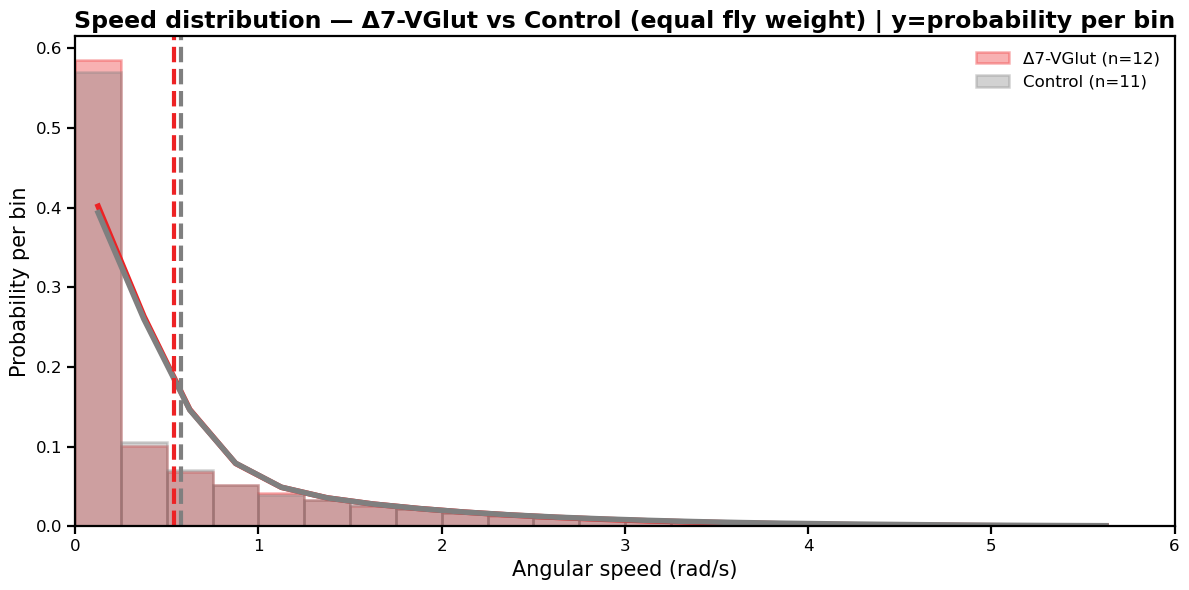

In [24]:
G1 = data_1['angular_velocity_distribution']
G2 = data_2['angular_velocity_distribution']

# Angular speed, equal fly weight, nice bins, x-range clipped, y as PROBABILITY (never >1)
out = plot_two_group_hist_pretty(
    G1, G2,
    as_speed=True,
    x_range=(0, 6),
    bins=np.arange(0, 6, 0.25),
    y_mode='probability',              # <- caps bars ≤ 1
    per_fly_equal_weight=True,
    colors=('#ed2224','tab:gray'),
    labels=('Δ7-VGlut','Control'),
    sigma_bins=1.5
)


In [25]:
def plot_two_group_hist_pretty_bump_amplitude(
    group1_bump_dict, group2_bump_dict,
    trials=None,
    abs_amplitude=False,             # True -> |amplitude|, usually False
    x_range=None,                    # (xmin, xmax) or None
    bins='auto',                     # int or array; if 'auto'+x_range, ~60 bins across range
    y_mode='density',                # 'density' (area≈1) or 'probability' (per bin, ≤1)
    per_fly_equal_weight=True,       # average per-fly histograms so each fly counts once
    colors=('tab:blue','tab:red'),
    labels=('Group 1','Group 2'),
    sigma_bins=1.5,                  # Gaussian smoothing of bar heights (in *bins*); 0 disables
    bar_alpha=0.35,
    bar_edge_lw=1.8,
    line_lw=4.0,
    figsize=(12,6),
    title=None,
    xlabel="Bump amplitude (a.u.)"
):
    """
    group*_bump_dict: e.g. data_X['bump_amplitude']
      mapping (fly_id, trial_id) -> list/array of per-frame bump amplitudes.
    'trials' can be ['001','004'] or None for all.
    """

    # ----- helpers (local; no external deps) -----
    def _group_data_by_fly(data_dict, trials=None, transform=None):
        wanted = None if trials is None else {str(t).zfill(3) for t in trials}
        by_fly = {}
        for (fid, tr), arrlist in data_dict.items():
            tr = str(tr).zfill(3)
            if (wanted is not None) and (tr not in wanted):
                continue
            seq = arrlist if isinstance(arrlist, (list, tuple)) else [arrlist]
            for a in seq:
                a = np.asarray(a).ravel()
                if a.size == 0: 
                    continue
                if transform is not None:
                    a = transform(a)
                a = a[np.isfinite(a)]
                if a.size == 0:
                    continue
                by_fly.setdefault(fid, []).append(a)
        # concat per fly
        for fid, chunks in list(by_fly.items()):
            by_fly[fid] = np.concatenate(chunks) if chunks else np.array([])
            if by_fly[fid].size == 0:
                by_fly.pop(fid, None)
        return by_fly

    def _hist_density(arr, edges):
        h, _ = np.histogram(arr, bins=edges, density=True)
        return h  # area≈1

    def _gaussian_smooth(y, sigma_bins=1.0):
        if not sigma_bins or sigma_bins <= 0:
            return y
        radius = int(max(3, np.ceil(4 * sigma_bins)))
        x = np.arange(-radius, radius + 1)
        k = np.exp(-(x**2) / (2 * sigma_bins**2))
        k /= k.sum()
        ypad = np.pad(y, (radius, radius), mode="edge")
        z = np.convolve(ypad, k, mode="same")[radius:-radius]
        return z

    transform = (np.abs if abs_amplitude else None)

    # ----- gather per-fly data -----
    g1 = _group_data_by_fly(group1_bump_dict, trials=trials, transform=transform)
    g2 = _group_data_by_fly(group2_bump_dict, trials=trials, transform=transform)
    if len(g1) == 0 or len(g2) == 0:
        raise ValueError("One of the groups has no usable fly data.")

    # ----- shared bin edges -----
    pooled = np.concatenate([np.concatenate(list(g1.values())),
                             np.concatenate(list(g2.values()))])
    if isinstance(bins, (list, tuple, np.ndarray)):
        edges = np.asarray(bins)
    else:
        if (x_range is not None) and (bins == 'auto'):
            edges = np.linspace(x_range[0], x_range[1], 61)  # ~60 bins across range
        else:
            edges = np.histogram_bin_edges(pooled, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    width   = np.diff(edges)

    # ----- bar heights per group (optionally equal-fly weighting) -----
    def _group_bars(by_fly):
        if per_fly_equal_weight:
            mats = []
            for arr in by_fly.values():
                h = _hist_density(arr, edges)                # density
                if y_mode == 'probability':
                    h = h * width                            # probability per bin
                mats.append(h)
            D = np.vstack(mats)
            y = np.nanmean(D, axis=0) if D.size else np.zeros(edges.size-1)
        else:
            all_arr = np.concatenate(list(by_fly.values()))
            h = _hist_density(all_arr, edges)                 # density
            y = h * width if y_mode == 'probability' else h
        return y

    d1 = _group_bars(g1)
    d2 = _group_bars(g2)

    # ----- smooth for line -----
    d1_s = _gaussian_smooth(d1, sigma_bins=sigma_bins)
    d2_s = _gaussian_smooth(d2, sigma_bins=sigma_bins)

    # ----- group means (for dashed lines) -----
    if per_fly_equal_weight:
        mean1 = float(np.mean([np.mean(v) for v in g1.values()]))
        mean2 = float(np.mean([np.mean(v) for v in g2.values()]))
    else:
        mean1 = float(np.mean(np.concatenate(list(g1.values()))))
        mean2 = float(np.mean(np.concatenate(list(g2.values()))))

    # ----- plot -----
    plt.figure(figsize=figsize)

    ylabel = "Density" if y_mode == 'density' else "Probability per bin"
    plt.bar(centers, d1, width=width, color=colors[0], alpha=bar_alpha,
            edgecolor=colors[0], linewidth=bar_edge_lw, label=f"{labels[0]} (n={len(g1)})")
    plt.bar(centers, d2, width=width, color=colors[1], alpha=bar_alpha,
            edgecolor=colors[1], linewidth=bar_edge_lw, label=f"{labels[1]} (n={len(g2)})")

    plt.plot(centers, d1_s, color=colors[0], lw=line_lw)
    plt.plot(centers, d2_s, color=colors[1], lw=line_lw)

    plt.axvline(mean1, color=colors[0], lw=max(1.0, line_lw-1), ls='--')
    plt.axvline(mean2, color=colors[1], lw=max(1.0, line_lw-1), ls='--')

    plt.xlabel(xlabel, fontsize=15)
    plt.ylabel(ylabel, fontsize=15)
    if title is None:
        title = f"Bump amplitude distribution — {labels[0]} vs {labels[1]}"
        if per_fly_equal_weight: title += " (equal fly weight)"
        if y_mode == 'probability':    title += " | y=probability per bin"
    plt.title(title, fontsize=17, weight='bold')
    if x_range is not None:
        plt.xlim(*x_range)
    plt.ylim(bottom=0)
    ax = plt.gca()
    ax.tick_params(axis='both', labelsize=12, width=1.6, length=6)
    for sp in ax.spines.values():
        sp.set_linewidth(1.6)
    plt.legend(frameon=False, fontsize=12)
    plt.tight_layout()
    #plt.savefig('delta7_syt6s_EPG_shi_cl_Bump_Amplitude_histogram_max_min.svg', format='svg')
    plt.show()

    return {
        "edges": edges, "centers": centers,
        "y_group1": d1, "y_group2": d2,
        "n_flies_group1": len(g1), "n_flies_group2": len(g2),
        "mean_group1": mean1, "mean_group2": mean2,
        "y_mode": y_mode, "per_fly_equal_weight": per_fly_equal_weight
    }


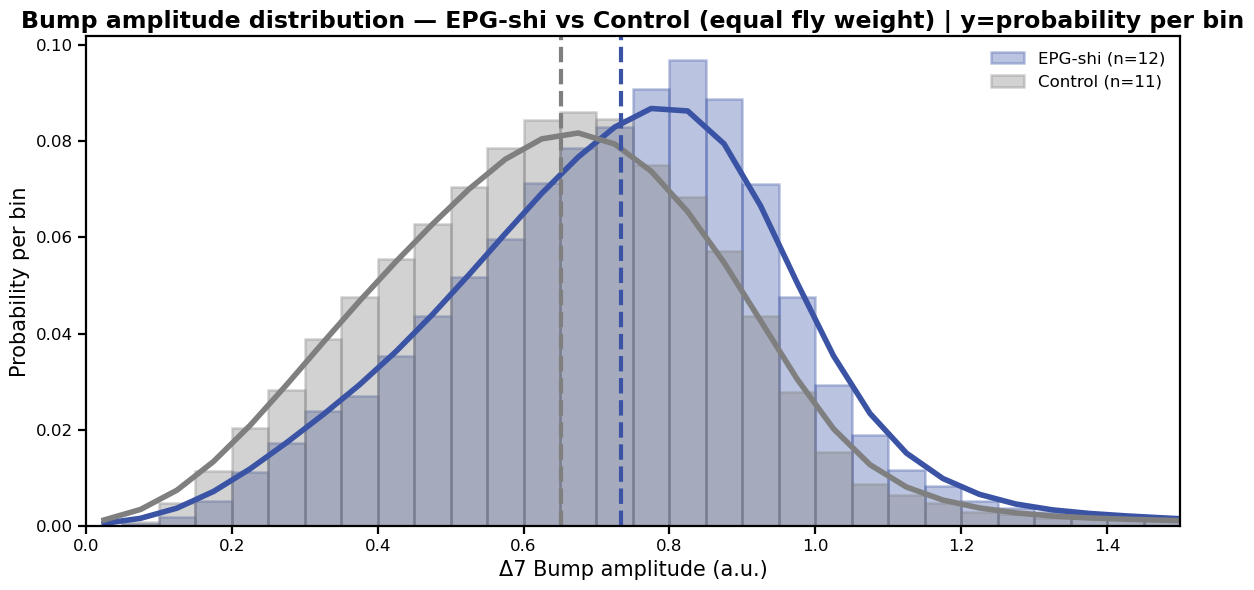

In [26]:
G1 = data_1['bump_amplitude_distribution']   # dict: (fly_id, trial_id) -> [arrays]
G2 = data_2['bump_amplitude_distribution']

out = plot_two_group_hist_pretty_bump_amplitude(
    G1, G2,
    trials=None,                      # or ['001','004']
    abs_amplitude=False,
    x_range=(0, 1.5),                   # clamp if you like
    bins=np.arange(0, 5.05, 0.05),    # explicit bins look great
    y_mode='probability',             # bars never >1
    per_fly_equal_weight=True,
    colors=('#3a53a4','tab:gray'),
    labels=('EPG-shi','Control'),
    sigma_bins=1.5,
    xlabel="Δ7 Bump amplitude (a.u.)"
)
